# Initial Analyses of the Engagement Survey  
Survey is hosted in the Thrive's AGOL account and is being filled in slowly.  
This analyses is aiming to find **gaps and strengths** of the current state of the engagement.

In [187]:
print("ready!")

ready!


In [188]:
color = ['#3064B2', '#625181','#008FA8', '#F68A46', '#f05133', '#ffc526', '#93a221' ]
charts_folder = r"C:\Git_Repo\thrive-data-portal\stakeholder-map\PY\survey-results"

## Acquire Data

In [225]:
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Start a session
session = requests.Session()

query_url = "https://services3.arcgis.com/xpR2E2r2KmCE5hF3/ArcGIS/rest/services/survey123_a2c60388714343fdba1dd544d47ca769/FeatureServer/0/query?where=1%3D1&objectIds=&geometry=&geometryType=esriGeometryEnvelope&inSR=&spatialRel=esriSpatialRelIntersects&resultType=none&distance=0.0&units=esriSRUnit_Meter&outDistance=&relationParam=&returnGeodetic=false&outFields=*&returnGeometry=false&featureEncoding=esriDefault&multipatchOption=xyFootprint&maxAllowableOffset=&geometryPrecision=&outSR=&defaultSR=&datumTransformation=&applyVCSProjection=false&returnIdsOnly=false&returnUniqueIdsOnly=false&returnCountOnly=false&returnExtentOnly=false&returnQueryGeometry=false&returnDistinctValues=false&cacheHint=false&collation=&orderByFields=&groupByFieldsForStatistics=&returnAggIds=false&outStatistics=&having=&resultOffset=&resultRecordCount=&returnZ=false&returnM=false&returnTrueCurves=false&returnExceededLimitFeatures=true&quantizationParameters=&sqlFormat=none&f=pjson&token="

headers = {
    "Content-Type": "application/json",
    "Accept": "application/json",
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

r = requests.get( query_url )
data = r.json()

data

{'objectIdFieldName': 'objectid',
 'uniqueIdField': {'name': 'objectid', 'isSystemMaintained': True},
 'globalIdFieldName': 'globalid',
 'serverGens': {'minServerGen': 620013, 'serverGen': 620013},
 'geometryType': 'esriGeometryPoint',
 'spatialReference': {'wkid': 4326, 'latestWkid': 4326},
 'fields': [{'name': 'objectid',
   'type': 'esriFieldTypeOID',
   'alias': 'ObjectID',
   'sqlType': 'sqlTypeOther',
   'domain': None,
   'defaultValue': None},
  {'name': 'globalid',
   'type': 'esriFieldTypeGlobalID',
   'alias': 'GlobalID',
   'sqlType': 'sqlTypeOther',
   'length': 38,
   'domain': None,
   'defaultValue': None},
  {'name': 'CreationDate',
   'type': 'esriFieldTypeDate',
   'alias': 'CreationDate',
   'sqlType': 'sqlTypeOther',
   'length': 8,
   'domain': None,
   'defaultValue': None},
  {'name': 'Creator',
   'type': 'esriFieldTypeString',
   'alias': 'Creator',
   'sqlType': 'sqlTypeOther',
   'length': 128,
   'domain': None,
   'defaultValue': None},
  {'name': 'EditDat

In [226]:
pd.set_option("display.max_columns", None )
columns  = [(i['name'] , i['alias']) for i in data['fields']]

df = pd.DataFrame([i['attributes'] for i in data['features']])
print( df.shape[0] , "rows" )
df.head()

77 rows


,objectid,globalid,CreationDate,Creator,EditDate,Editor,name,organization_name,your_role_or_title,email_address,sectors_you_primarily_work_in,where_are_your_projects_primari,define_area_where_you_work,Other_define_area_where_you_wor,do_you_maintain_geodata,may_thrive_contact_you_to_share,do_you_use_data_to_support_work,are_data_sources_private_public,how_often_have_you_used_dataset,rate_data_availabile,what_do_you_primarily_use_data,Other_what_do_you_use_data,have_you_used_Thrive_tools,which_thrive_tools_have_you_use,other_thrive_tools_have_you_use,when_do_you_use_Thrive_tool,how_do_you_access_thrive_tool,other_tools_or_platforms_used,other_tools_or_platforms__other,one_thing_you_would_want_in_hub,what_dataset_most_valuable,feat_most_used_existing_Thrive,challenges_using_thrive_data,project_name,location_citycountyregion,primary_sector,brief_description,project_name2,location_citycountyregion2,primary_sector2,brief_description2,project_name3,location_citycountyregion3,primary_sector3,brief_description3,past_project_help_to_understand,did_thrive_play_a_role,please_describe_thrives_role,priorities_currently_set_projec,interested_in_follup_call,telephone_number,willing_to_beta_test_hub,would_you_like_hub_updates,when_looking_at_our_region_what,when_looking_at_our_regio_other,please_explain_anything_else_we
0,8,11fbfaa8-2b04-4324-82f4-46d4b1c195d0,1770729419625,,1770729419625,,Kathy Ragon,"Dade County, Georgia",Grant Writer,kragon@dadecounty-ga.gov,Public,Georgia,County,None,Yes,Yes,Yes,Mostly public,Occasionally (some projects),Good - Data is available but so,Reporting_or_grant_compliance,None,No,None,None,None,None,"Google_Earth,Data_analysis_tools_(Excel_Tabl",None,View and layer interactive maps that show natu...,Pacel level data maintained by the County Tax ...,n/a,n/a,Dade County Community Forest Acquisition - Cur...,"Trenton, Dade County, GA","Conservation, outdoor recreation, economic dev...",Acquisition of 650 acres to create a publicly ...,Construction Career Center - Conceptual,"Trenton, Dade County, GA","Workforce Development, Economic Development",Conceptual development of a construction trade...,Dade County Sports Complex Park Improvements -...,"Trenton, Dade County, GA",Parks & Recreation / Community Infrastructure,Conceptual improvements to the Dade County Spo...,These are not necessarily past projects but an...,No,None,Priorities are set through a combination of ad...,Yes,706-657-4625,Yes,Yes,"Impact_reports,Dashboards,Interactive_maps",None,None
1,9,80d85303-8b56-421b-8a44-f2018432660e,1770744995249,mdtaylor_CHCRPA,1770744995249,mdtaylor_CHCRPA,Melissa Taylor,Chattanooga-Hamilton County Regional Planning ...,Director of Transportation Planning/MPO Coordi...,mdtaylor@chattanooga.gov,Public,"Tennessee,Georgia",Multi-county region,None,Yes,Yes,Yes,A mix of public and private,Frequently (most projects),Excellent - Most needed data is,"Analysis_and_research,Tracking_metrics_or_perf...",None,Yes,Interactive_Map:_Thrive_Regiona,None,"Early_planning_&_scoping,Monitoring_and_reporting",Desktop_computer,"ESRI_/_ArcGIS_products,Data_analysis_tools_(Ex...",None,priorities and/or needs across multiple jurisd...,Crash Data,None,None,Emergency Management/Alternative Truck Routing...,Metropolitan Planning Area (MPO's MPA Boundary...,Public,Address the bottlenecks and alternate routing ...,Strategic Bicycle and Pedestrian Network and I...,Chattanooga Urbanized Area and MPO's MPA,Public,Establish a base bike/ped network and determin...,Regional Transit Improvement Plan,Chattanooga Urbanized Area and MPO's MPA,Public,Development of a project list for Transit impr...,None,Yes,Advisory and connections to interested stakeho...,MPO's Regional Transportation Plan,Yes,423-260-7173,Yes,Yes,"Impact_reports,Dashboards,Interactive_maps",None,None
2,10,82cb68fb-c17c-4dea-897e-c35a849ccb3c,1770916366623,,1770916366623,,Suzanne Roach,Chattanooga State Community College,Solutions Development Manager,suzanne.roach@chattanoogastate.edu,Education,T

## Orgs by State

In [191]:
t = df[['organization_name','where_are_your_projects_primari']].copy()
t['loc'] = t['where_are_your_projects_primari'].str.split(",")

t = t.explode('loc')
t.groupby(['loc','organization_name'] , as_index=False).size().sort_values(by=['loc','size'], ascending=False)

,loc,organization_name,size
70,Tennessee,City of Chattanooga,7
98,Tennessee,TennGreen Land Conservancy,2
103,Tennessee,Tennessee Valley Authority,2
63,Tennessee,American Water,1
64,Tennessee,Appalachian Conservation Institute,1
...,...,...,...
4,Alabama,Southeast Conservation Corps,1
5,Alabama,Tanco Logistics LLC,1
6,Alabama,Tennessee Aquarium,1
8,Alabama,University of Tennessee at Chattanooga (UTC) /...,1


In [192]:
t.value_counts('loc').to_frame()

,count
loc,
Tennessee,54
Georgia,34
Southeastern_US,14
Alabama,12
National,8
International,1


In [193]:
col = 'sectors_you_primarily_work_in'
col_alias = [alias for name,alias in columns if name == col ]
print( col_alias )
t = df[[ col,'where_are_your_projects_primari']].copy()

t['loc'] = t['where_are_your_projects_primari'].str.split(",")
t['prim_sector'] = t[col].str.split(",")

t =  t[['loc','prim_sector']]
t = t.explode('prim_sector').explode('loc')

pt = pd.pivot_table(
    data = t,
    index = 'prim_sector',
    columns='loc',
    aggfunc=len,
    fill_value=0
)

pt['Total'] = pt.sum( axis=1 )
pt

['Sector(s) you primarily work in']


loc,Alabama,Georgia,International,National,Southeastern_US,Tennessee,Total
prim_sector,,,,,,,
Education,7,9,0,1,6,14,37
Non-profit,7,16,1,2,8,23,57
Philanthropic,5,4,0,0,3,6,18
Private,6,7,0,6,6,12,37
Public,9,26,0,2,9,34,80


In [194]:
pt2 = pt.drop(columns=['Total']).T
pt2['sum'] = pt2.sum(axis=1)
pt2 = pt2.sort_values('sum').drop(columns=['sum'])
pt2

prim_sector,Education,Non-profit,Philanthropic,Private,Public
loc,,,,,
International,0,1,0,0,0
National,1,2,0,6,2
Southeastern_US,6,8,3,6,9
Alabama,7,7,5,6,9
Georgia,9,16,4,7,26
Tennessee,14,23,6,12,34


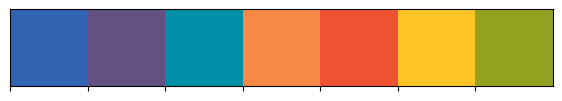

In [195]:
thrive_colors = sns.color_palette(color)
sns.palplot(thrive_colors)
plt.show()

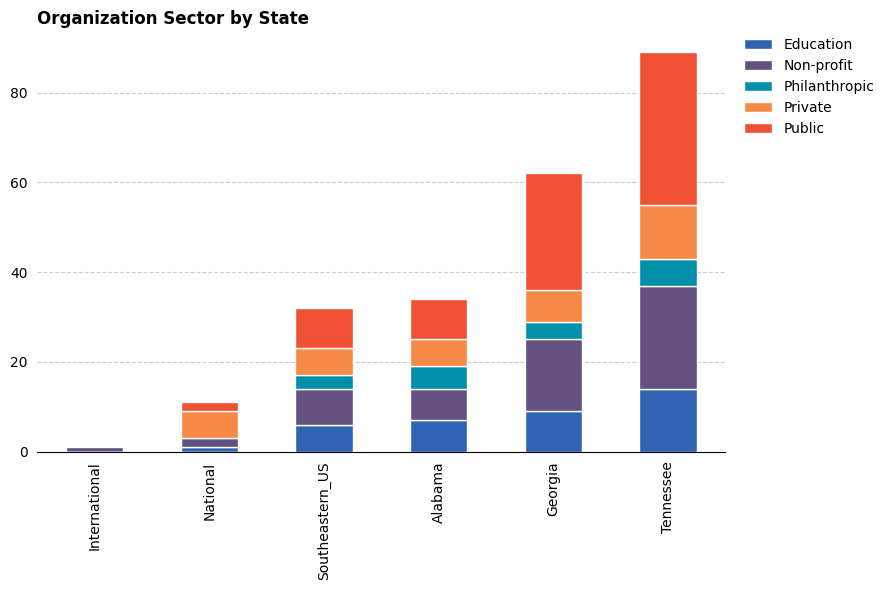

In [196]:
import os
fig,ax = plt.subplots( figsize = (9,6) )
pt2.plot(ax=ax, kind='bar',  stacked=True, zorder=2, ec='w', color=thrive_colors)

ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fancybox=False, frameon=False)
sns.despine( left=True )
ax.tick_params( axis='both', left=False, bottom=False )
ax.grid(axis='y', color="#999", alpha=0.5, ls="--")
ax.set_xlabel('')
ax.set_title("Organization Sector by State", loc='left', fontweight='bold')

fig.tight_layout()
fig.savefig(os.path.join(charts_folder, "sectorbyState.png") )

## Data and Tools

### Data Availability

In [197]:
col = 'rate_data_availabile'
col_alias = [alias for name,alias in columns if name == col ]
print( col_alias )

['How would you rate the availability of geospatial data your organization needs?']


In [198]:
t = df[['where_are_your_projects_primari', col ,'what_do_you_primarily_use_data']].copy()

t['prim_use'] = t['what_do_you_primarily_use_data'].str.split(",")
t['rate_data'] = t[col].str.split(" - " ).str[0]

t = t.explode('prim_use')
t = t[ ['prim_use','rate_data'] ]

pt = pd.pivot_table(
    data=t,
    index="prim_use",
    columns="rate_data",
    aggfunc=len,
    fill_value=0
).reindex(columns=["Excellent", "Good", "Fair", "Poor"], fill_value=0)

pt['sum'] = pt.sum(axis=1)
pt.index = pt.index.str.replace("_", " ")
pt

rate_data,Excellent,Good,Fair,Poor,sum
prim_use,,,,,
Analysis and research,9,38,13,1,61
Community Engagement,8,24,7,1,40
Decision-making,9,35,11,1,56
Reporting or grant compliance,6,24,9,1,40
Setting organization or project,5,27,8,1,41
Tracking metrics or performance,9,21,8,1,39
other,1,3,2,0,6


In [199]:

t = df[['where_are_your_projects_primari','rate_data_availabile','what_do_you_primarily_use_data']].copy()
t['loc'] = t['where_are_your_projects_primari'].str.split(",")
t['prim_use'] = t['what_do_you_primarily_use_data'].str.split(",")

t['rate_data'] = t['rate_data_availabile'].str.split(" - " ).str[0]

t = t[['loc','prim_use','rate_data']]

t = t.explode('loc').explode('prim_use')

gr = t.groupby(['loc','prim_use','rate_data'], as_index=False).size()
gr = gr[ gr['prim_use'] != 'other' ]
gr = gr[ ~gr['loc'].isin(['National','International']) ]
gr['prim_use'] = gr['prim_use'].str.replace("_",' ')

pt = pd.pivot_table(
    data = gr,
    index = ['loc','rate_data'],
    columns=['prim_use'],
    values="size", fill_value=0
).astype(int)

pt

prim_use                   Analysis and research  Community Engagement  \
loc             rate_data                                                
Alabama         Excellent                      1                     0   
                Fair                           3                     1   
                Good                           5                     5   
                Poor                           1                     1   
Georgia         Excellent                      5                     4   
                Fair                           5                     4   
                Good                          13                    11   
Southeastern_US Excellent                      3                     2   
                Fair                           1                     1   
                Good                           7                     8   
Tennessee       Excellent                      6                     5   
                Fair                           9                     5   
                Good                          31                    19   

prim_use                   Decision-making  Reporting or grant compliance  \
loc             rate_data                                                   
Alabama         Excellent                2                              1   
                Fair                     2                              2   
                Good                     5                              1   
                Poor                     1                              1   
Georgia         Excellent                6                              4   
                Fair                     5                              4   
                Good                    14                              8   
Southeastern_US Excellent                3                              1   
                Fair                     0                              0   
                Good                     7                              2   
Tennessee       Excellent                5                              4   
                Fair                     6                              6   
                Good                    29                             20   

prim_use                   Setting organization or project  \
loc             rate_data                                    
Alabama         Excellent                                1   
                Fair                                     2   
                Good                                     4   
                Poor                                     1   
Georgia         Excellent                                3   
                Fair                                     4   
                Good                                    11   
Southeastern_US Excellent                                1   
                Fair                                     0   
                Good                                     5   
Tennessee       Excellent                                4   
                Fair                                     5   
                Good                                    23   

prim_use                   Tracking metrics or performance  
loc             rate_data                                   
Alabama         Excellent                                2  
                Fair                                     0  
                Good                                     3  
                Poor                                     1  
Georgia         Excellent                                6  
                Fair                                     3  
                Good                                     6  
Southeastern_US Excellent                                3  
                Fair                                     0  
                Good                                     4  
Tennessee       Excellent                                6  
         

rate_data,Excellent,Good,Fair,Poor
prim_use,,,,
Analysis and research,1.0,5.0,3.0,1.0
Community Engagement,0.0,5.0,1.0,1.0
Decision-making,2.0,5.0,2.0,1.0
Reporting or grant compliance,1.0,1.0,2.0,1.0
Setting organization or project,1.0,4.0,2.0,1.0
Tracking metrics or performance,2.0,3.0,0.0,1.0


rate_data,Excellent,Good,Fair,Poor
prim_use,,,,
Analysis and research,5.0,13.0,5.0,0
Community Engagement,4.0,11.0,4.0,0
Decision-making,6.0,14.0,5.0,0
Reporting or grant compliance,4.0,8.0,4.0,0
Setting organization or project,3.0,11.0,4.0,0
Tracking metrics or performance,6.0,6.0,3.0,0


rate_data,Excellent,Good,Fair,Poor
prim_use,,,,
Analysis and research,3.0,7.0,1.0,0
Community Engagement,2.0,8.0,1.0,0
Decision-making,3.0,7.0,0.0,0
Reporting or grant compliance,1.0,2.0,0.0,0
Setting organization or project,1.0,5.0,0.0,0
Tracking metrics or performance,3.0,4.0,0.0,0


rate_data,Excellent,Good,Fair,Poor
prim_use,,,,
Analysis and research,6.0,31.0,9.0,0
Community Engagement,5.0,19.0,5.0,0
Decision-making,5.0,29.0,6.0,0
Reporting or grant compliance,4.0,20.0,6.0,0
Setting organization or project,4.0,23.0,5.0,0
Tracking metrics or performance,6.0,17.0,5.0,0


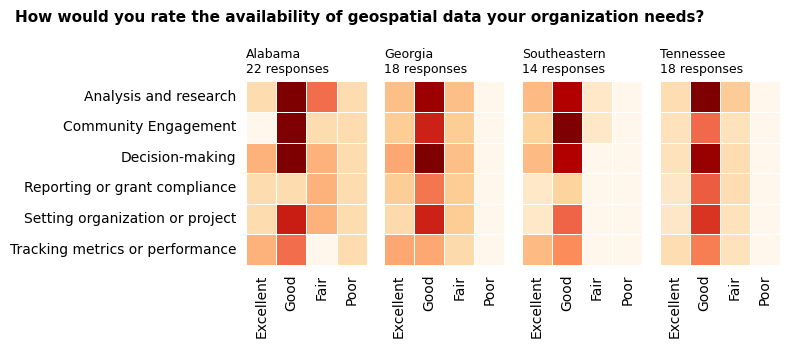

In [200]:
fig,axs = plt.subplots( ncols= gr['loc'].nunique() , sharex=True, sharey=True, figsize=(8,3.5))

count = 0
for i,loc in gr.groupby('loc'):
    ax = axs[count]

    ax.set_title( f"{i.split("_")[0]}\n{loc.shape[0]} responses" , loc='left', fontsize=9 )

    temp = loc.copy()
    temp = temp.drop(columns=['loc'])
    temp = temp.pivot_table( index = 'prim_use', columns=['rate_data'], values='size' , fill_value= 0)

    if "Poor" not in temp.columns:
        temp['Poor'] = 0 * temp.shape[0]

    temp = temp[['Excellent','Good','Fair','Poor']]

    display( temp )

    sns.heatmap( 
        ax=ax, 
        data = temp,
        cmap='OrRd' , linecolor='w', linewidths=0.5,
        cbar=False
    )
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.tick_params( axis='both', left=False, bottom=False )

    ax.set_xticklabels( labels = ax.get_xticklabels(), rotation=90 )

    count = count + 1

fig.suptitle( col_alias[0] , x=0.025, ha='left', fontweight='bold', fontsize=11)
fig.tight_layout( w_pad=1.25 )
fig.savefig( os.path.join( charts_folder, "dataAvail.png") )

###  'which_thrive_tools_have_you_use'

In [201]:
col = 'which_thrive_tools_have_you_use'
col_alias = [alias for name,alias in columns if name == col ]
print( col_alias )

t = df.copy()
t = t[['sectors_you_primarily_work_in', col]]
t['prim-tool'] = t[col].str.split(",")
t['prim-sector'] = t['sectors_you_primarily_work_in'].str.split(",")

t = t[['prim-tool','prim-sector']].explode('prim-tool').explode('prim-sector')

pt = pd.pivot_table(
    data = t,
    index = 'prim-tool',
    columns= 'prim-sector',
    aggfunc= len, fill_value=0
    )

pt.index = [ f"{i.replace("_", " ").replace(": ",'\n')}..." if i != 'other' else "Other" for i in pt.index ]
pt['sum'] = pt.sum( axis=1 )
pt = pt.sort_values( by='sum').drop( columns=['sum'])

pt = pt.reindex(  ["Other"]  + list(pt.index[pt.index != "Other" ]))

pt

['Which Thrive tools have you used?']


prim-sector,Education,Non-profit,Philanthropic,Private,Public
Other,1,0,0,0,1
Interactive Map\nBroadband Asse...,0,0,0,0,1
Dashboard\nTransportation & Inf...,1,1,1,3,5
Dashboard\nCradle of Southern A...,2,7,1,1,4
Interactive Map\nThrive Regiona...,2,1,1,6,5
Dashboard\nCounty by County Dat...,3,2,3,5,6


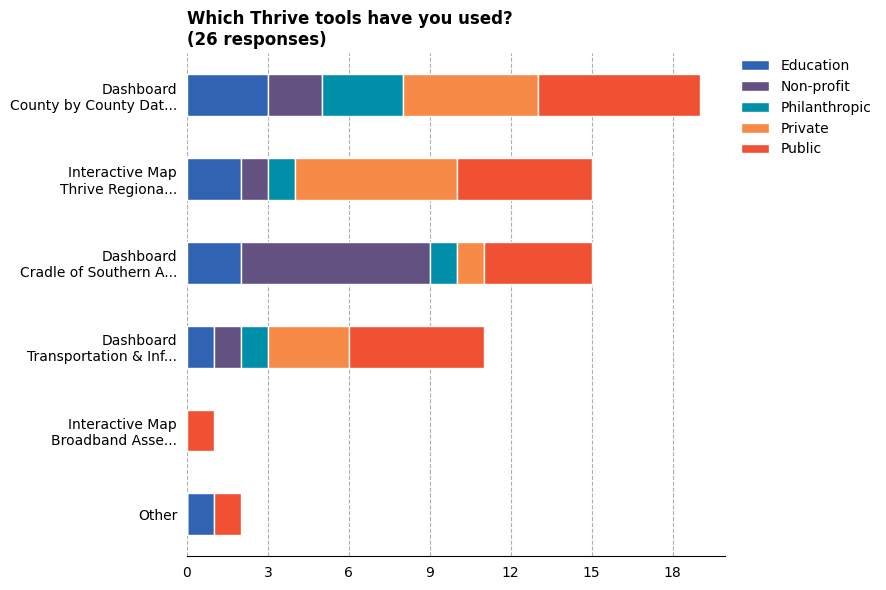

In [202]:
import os
fig,ax = plt.subplots( figsize = (9,6) )
pt.plot(ax=ax, kind='barh',  stacked=True, zorder=2, ec='w', color=thrive_colors)

ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fancybox=False, frameon=False)
sns.despine( left=True )
ax.tick_params( axis='both', left=False, bottom=False )
ax.grid(axis='x', color="#656364", alpha=0.5, ls="--")
ax.set_xlabel('')

num_ents = df.dropna(subset=col).shape[0]
f"{num_ents} responses to {col_alias[0]}"

ax.set_title( f"Which Thrive tools have you used?\n({num_ents} responses)", loc='left', fontweight='bold')
ax.set_xticks( list( range(0,21,3) ))

fig.tight_layout()
fig.savefig(os.path.join(charts_folder, "ThriveToolUse.png") )

### 'do_you_use_data_to_support_work'

In [172]:
col = 'do_you_use_data_to_support_work'
col_alias = [alias for name,alias in columns if name == col ]
print( col_alias )

df[col].value_counts()

['Do you use data to support your work or projects?']


do_you_use_data_to_support_work
Yes    73
No      4
Name: count, dtype: int64

In [173]:
# one_thing_you_would_want_in_hub	what_dataset_most_valuable
col = 'one_thing_you_would_want_in_hub'
df.dropna(subset=col)[col].value_counts()

one_thing_you_would_want_in_hub
View and layer interactive maps that show natural assets, infrastructure and community data.  Download maps, datasets, or summary reports for planning and grant development                                                                      1
priorities and/or needs across multiple jurisdictions                                                                                                                                                                                             1
Map ALL Utility Infrastructure! Customize reports. Understand historical/cultural significance of the region.                                                                                                                                     1
Raw date in downloadable form                                                                                                                                                                                                               

Valuable datasets

In [174]:
col = 'what_dataset_most_valuable'
sets = [[n.strip() for n in i.split(",")] for i in df[df[col].notnull()][col].values]

flat = [item for sublist in sets for item in sublist]
sets =pd.Series(flat)

sets.values

array(['Pacel level data maintained by the County Tax Assessor',
       'Crash Data', 'JobsEQ (workforce data). GISWebTech (GURU data).',
       'US DOT', 'Thrive',
       'USGS/State DNR Watershed Basins (HUC2 through HUC12) and National Park/Forest boundaries',
       'Fish Counts by specific Wildlife Resource Agency by State',
       'PAD-US', 'ParkServe', 'CDC PLACES',
       "US Census's wide range of demographic and economic data",
       'Parcels', 'GIS mapping', 'Survey responses',
       'trail counters and placer ai data',
       'analytics from our membership platform + website traffic',
       'Roadways', 'Census ACS 5-year', 'stormwater inspection',
       'enforcement', 'and tracking software', 'Datasets we’ve paid for',
       'city and county', 'Private', 'Salesforce member reporting-hours',
       'accomplishnents', 'demographics', 'strategic growth', 'impact',
       'financial', 'GIS', 'USFS and NPS', 'Road', 'Parcel',
       'Infrastructure', 'demographic', 'TN Stat

In [175]:
import re
from collections import Counter

STOPWORDS = {
    'a','an','the','and','or','of','to','in','for','on','with','is','are','that',
    'it','this','we','our','i','be','as','at','by','was','from','have','has','not',
    'do','can','all','more','so','but','if','about','use','used','need','would',
    'like','data','want','will','also','us','its','any','my','their','which',
    'there','been','when','they','what','who',
}

def tokenize(text):
    return [w for w in re.findall(r"[a-z]+(?:'[a-z]+)?", text.lower()) if w not in STOPWORDS and len(w) > 2]

tokens = [t for s in sets for t in tokenize(s)]
bigrams = [f"{tokens[i]} {tokens[i+1]}" for i in range(len(tokens)-1)]

word_freq = Counter(tokens).most_common(20)
bigram_freq = Counter(bigrams).most_common(15)

print("=== Top single words ===")
for word, count in word_freq:
    print(f"  {count:>3}x  {word}")

print("\n=== Top 2-word phrases ===")
for phrase, count in bigram_freq:
    print(f"  {count:>3}x  {phrase}")



=== Top single words ===
   11x  gis
    5x  county
    4x  state
    4x  census
    3x  through
    3x  national
    3x  parcels
    3x  survey
    3x  datasets
    3x  labor
    3x  wetlands
    2x  tax
    2x  thrive
    2x  usgs
    2x  huc
    2x  boundaries
    2x  wildlife
    2x  demographic
    2x  economic
    2x  placer

=== Top 2-word phrases ===
    3x  county gis
    2x  bureau labor
    2x  labor statistics
    2x  business analyst
    1x  pacel level
    1x  level maintained
    1x  maintained county
    1x  county tax
    1x  tax assessor
    1x  assessor crash
    1x  crash jobseq
    1x  jobseq workforce
    1x  workforce giswebtech
    1x  giswebtech guru
    1x  guru dot


In [44]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np

# --- settings ---
N_TOPICS = 4        # adjust: how many themes to discover
N_TOP_WORDS = 8     # words to show per topic

docs = sets.dropna().tolist()   # one string per survey response

vectorizer = CountVectorizer(
    stop_words='english',
    min_df=1,
    token_pattern=r"[a-z]{3,}",
)
X = vectorizer.fit_transform(docs)
vocab = vectorizer.get_feature_names_out()
word_counts = np.asarray(X.sum(axis=0)).flatten()  # total corpus count per term

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=200,
)
lda.fit(X)

print(f"=== LDA Topics (n={N_TOPICS}) ===\n")
for idx, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[:-N_TOP_WORDS - 1:-1]
    top_words = [(vocab[i], int(word_counts[i])) for i in top_indices]
    words_str = ", ".join(f"{w} ({c}x)" for w, c in top_words)
    print(f"Topic {idx+1}: {words_str}")

# --- show dominant topic per response ---
doc_topics = lda.transform(X)
dominant = doc_topics.argmax(axis=1)
import pandas as pd
topic_df = pd.DataFrame({'response': docs, 'topic': dominant + 1})
print("\n--- Response → Topic assignment ---")
print(topic_df.to_string(index=False))


=== LDA Topics (n=4) ===

Topic 1: gis (11x), county (5x), wetlands (3x), survey (3x), private (2x), national (3x), census (5x), wildlife (2x)
Topic 2: census (5x), data (16x), state (4x), huc (2x), demographic (2x), transportation (2x), internal (2x), american (2x)
Topic 3: data (16x), placer (2x), thrive (2x), species (2x), collect (2x), datasets (3x), community (2x), resources (2x)
Topic 4: data (16x), esri (3x), labor (3x), parcels (3x), gis (11x), analyst (2x), business (2x), statistics (2x)

--- Response → Topic assignment ---
                                                                                                                                                                           response  topic
                                                                                                                             Pacel level data maintained by the County Tax Assessor      4
                                                                                       

## Are there a few more things we'd like to highlight?

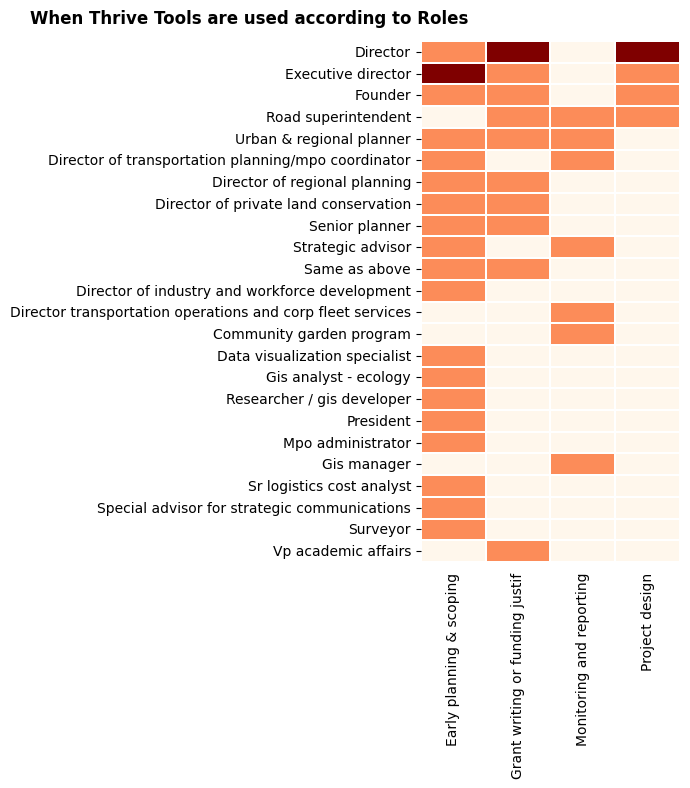

In [259]:
df['your_role_or_title'] = df['your_role_or_title'].str.strip().str.upper().str.capitalize()
t = df.copy()
t = t.dropna( subset=['when_do_you_use_Thrive_tool'])

t['when_do_you_use_Thrive_tool'] = t['when_do_you_use_Thrive_tool'].str.split(",")

t = t[['objectid','your_role_or_title','when_do_you_use_Thrive_tool']].set_index(['objectid','your_role_or_title']).explode('when_do_you_use_Thrive_tool').reset_index()

pt = t.pivot_table(
    index='your_role_or_title',
    columns='when_do_you_use_Thrive_tool',
    aggfunc=len,
    values="objectid", fill_value=0
)

pt['sum'] = pt.sum(axis=1)
pt = pt.sort_values( by='sum' , ascending=False ).drop(columns=['sum'])

pt.index = [i.replace("_",' ') for i in pt.index]
pt.columns = [i.replace("_",' ') for i in pt.columns]

fig,ax = plt.subplots(figsize = (7,8) ) 
sns.heatmap(
    pt, ax=ax,
    cmap='OrRd',
    cbar=False,
    linecolor='w', linewidths=0.25
)

ax.tick_params( axis='both', left='False', bottom=False )

ax.set_ylabel('')
ax.set_xlabel('')

fig.suptitle("When Thrive Tools are used according to Roles", x=0.05, ha='left', fontweight='bold')

fig.tight_layout()
fig.savefig(os.path.join(charts_folder, "whenThriveTools.png") );

In [266]:
col = 'when_looking_at_our_region_what'
col_alias = [alias for name,alias in columns if name == col ]
print( col_alias )

['When looking at our region, what tools would help you understand the relationship between our natural assets, our transportation & infrastructure, and our community prosperity?']


In [308]:
df['your_role_or_title'] = df['your_role_or_title'].str.strip().str.upper().str.capitalize()
t = df.copy()
t = t.dropna( subset=col )

t[col] = t[col].str.split(",")
t['prim_use'] = t['what_do_you_primarily_use_data'].str.split(",")

t = t[['objectid',col, 'prim_use']]

t = t.set_index('prim_use').explode(col).reset_index().set_index(col).explode('prim_use').reset_index()

pt = t.pivot_table(
    index = 'prim_use',
    columns=col,
    values='objectid', fill_value=0,
    aggfunc=len
)

pt.index = [i.replace("_"," ") for i in pt.index]
pt['sum'] = pt.sum(axis=1)
pt = pt.sort_values(by='sum').drop(columns=['sum'])
pt

when_looking_at_our_region_what,Blogs,Dashboards,Impact_reports,Interactive_maps,other
other,0,4,3,6,1
Community Engagement,9,28,26,36,1
Reporting or grant compliance,6,29,27,38,1
Setting organization or project,6,27,30,38,2
Tracking metrics or performance,5,33,27,38,1
Decision-making,8,39,33,52,2
Analysis and research,11,42,37,57,3


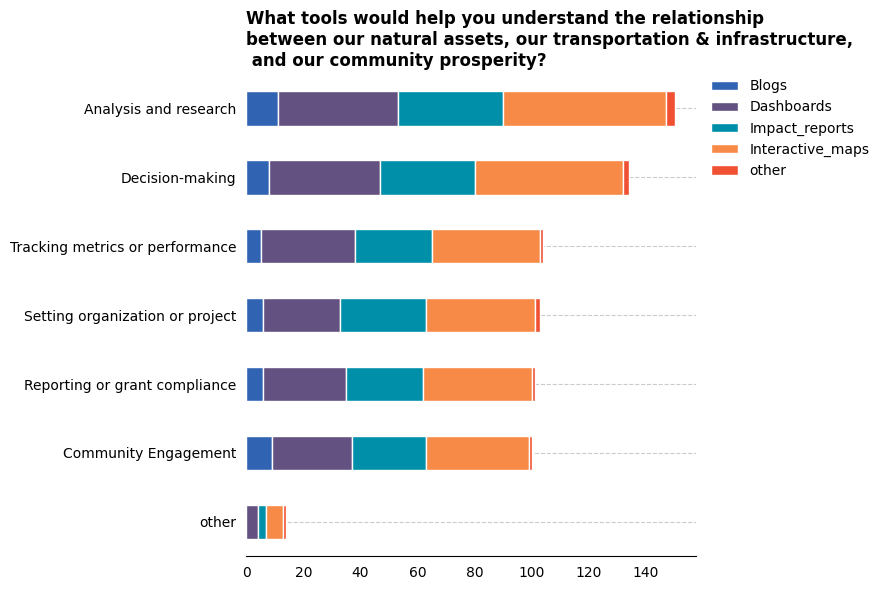

In [310]:
fig,ax = plt.subplots( figsize = (9,6) )
pt.plot(ax=ax, kind='barh',  stacked=True, zorder=2, ec='w', color=thrive_colors)

ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fancybox=False, frameon=False)
sns.despine( left=True )
ax.tick_params( axis='both', left=False, bottom=False )
ax.grid(axis='y', color="#999", alpha=0.5, ls="--")
ax.set_xlabel('')
ax.set_title("What tools would help you understand the relationship\nbetween our natural assets, our transportation & infrastructure,\n and our community prosperity?", loc='left', fontweight='bold')

fig.tight_layout()
# fig.savefig(os.path.join(charts_folder, "sectorbyState.png") )

In [339]:
list(pt.sum( axis=0).sort_values().index)

['Third-party planning tools',
 'QGIS',
 'other',
 'Custom web mapping applications',
 'Custom code',
 'Google Earth',
 'ESRI / ArcGIS products',
 'Data analysis tools']

In [371]:
c1 = 'what_do_you_primarily_use_data'
c2 = 'other_tools_or_platforms_used'
t = df[[c1,c2,'objectid']].copy()

t[c2] = t[c2].fillna('No Experience')

for i in [c1,c2]:
    t[i] = t[i].str.replace("_"," ").str.split(",")


t = t.set_index(c1).explode(c2).reset_index() \
    .set_index(c2).explode(c1).reset_index()

pt = t.pivot_table(
    index = c1,
    columns=c2,
    values='objectid', fill_value=0,
    aggfunc=len
)

pt.columns = [i.split(" (")[0] for i in pt.columns]

pt = pt[list(pt.sum( axis=0).sort_values().index)]


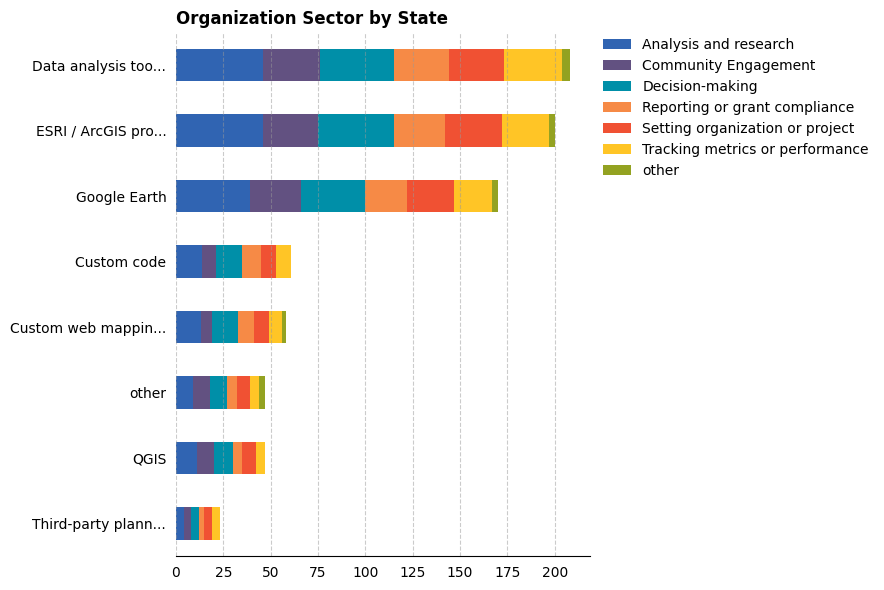

In [376]:

fig,ax = plt.subplots( figsize = (9,6) )
pt.columns = [i if len(i) < 18 else f"{i[0:17]}..." for i in pt.columns]
pt.T.plot(ax=ax, kind="barh", stacked=True , color=thrive_colors )

ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fancybox=False, frameon=False)
sns.despine( left=True )
ax.tick_params( axis='both', left=False, bottom=False )
ax.grid(axis='x', color="#999", alpha=0.5, ls="--")
ax.set_xlabel('')
ax.set_title("Organization Sector by State", loc='left', fontweight='bold')

fig.tight_layout()
fig.savefig(os.path.join(charts_folder, "DataUse-ToolExperience.png") )